In [1]:
%matplotlib inline
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
from numpy import empty
import xarray as xr
import pftnames
import cftime
import utils
import grainc_global
from scipy import stats, signal
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns

79


### user input

In [2]:
root           = f''
path_lst       = f'{root}/data/processed/lst_esacci_modis_2deg/'
path           = f'{root}/apps/CTSM_dev/DERECHO_OUT/'
dir_control    = f'{path}ihist.e52.IHistClm50BgcCrop.f19_g17.nostress_1980/'
dir_exps       = f'{path}harmonized_exps_lai_rep/'
dir_30         = f'{path}HSF_lai_exp1/'
HSF_default    = 1

YR1, YR2       = 1985, 2014
YR1LST, YR2LST = 2000, 2014
active_crops   = ['spring_wheat', 'corn', 'rice', 'soybean']
list_cfts      = ['temperate_corn', 'irrigated_temperate_corn',
                  'spring_wheat', 'irrigated_spring_wheat',
                  'soybean', 'irrigated_soybean', 
                  'rice', 'irrigated_rice',
                  'tropical_corn', 'irrigated_tropical_corn',
                  'tropical_soybean','irrigated_tropical_soybean']

### functions

#### merge CLM output files

In [3]:
def merge_CLM5_histfiles(path_in, YR1, YR2,  keep_cfts, historyfile='h3', vars=['HSF']):
    ''' Merge CLM output data into single dataset.'''

    # find relevant files matching years and file extension
    pattern = os.path.join(path_in, f'*clm2.{historyfile}.*.nc')
    files_all = sorted(glob.glob(pattern))

    if len(files_all) == 0:
        raise FileNotFoundError(f'No files found matching pattern {pattern}')

    files = []
    for f in files_all:
        try:
            year = int(f.split('.')[-2].split('-')[0])
            if YR1 <= year <= YR2:
                files.append(f)
        except Exception:
            continue

    if len(files) == 0:
        raise ValueError(f'No files found between {YR1} and {YR2}')
    elif len(files) < (YR2-YR1):
        raise ValueError(f'years not matching number of files')
        
    # open and append files
    var_lists = {var: [] for var in vars}
    ds_list = []
    for f in files:
        #print(int(f.split('.')[-2].split('-')[0]))
        ds =  utils.time_set_mid(xr.open_dataset(f), 'time')

        for var in vars:
            da = ds[var]
            if da.ndim == 3:
                da_out = da
            elif da.ndim == 2:
                # pft → grid
                da_out = grainc_global.reshape_1D_to_2Dgrid(var, ds, mask=None)
                da_out = da_out.rename({'pft': 'cft'})
                da_out = da_out.sel(cft=keep_cfts)
            else:
                print(f"Skipping {var}, unexpected dims")
                continue
            var_lists[var].append(da_out)
            da_out.close(), da.close
            del da, da_out

        ds.close()
        del ds

    # merge dataset with multiple variables
    ds_out = []
    for var in vars:
        da_concat = xr.concat(var_lists[var], dim="time")
        da_concat = da_concat.sortby("time")
        da_concat = da_concat.rename(var)
        ds_out.append(da_concat)

        da_concat.close()
        del da_concat

    ds_out = xr.merge(ds_out)
    
    # regrid longitude from [0,360] to [-180,180]
    ds_out = utils.lon_pm2idl(ds_out)
    
    return ds_out

#### obtain number of heat stress days during growing season for each year

##### for CLM trigger analysis

In [12]:
def CLM5_HSF_annual(path_in, YR1, YR2, HSF_default):
    ''' Check the occurrence of heat stressed days during the grain fill stage. 
        Some locations have the growing season overlapping two calendar years, which required some extra coding.'''
    years = np.arange(YR1, YR2+1)

    #create empty ds
    ds_out = []
        
    for year in years:
        if year == YR1:
            ds_2yrs = merge_CLM5_histfiles(path_in, year-1, year, list_cfts ,historyfile='h3', vars=['HSF','CPHASE', 'TVDAY'])
        else:
            # for every new year drop year-2 and add year
            ds_newyr = merge_CLM5_histfiles(path_in, year, year,list_cfts,
                                            historyfile='h3', vars=['HSF','CPHASE','TVDAY'])
            # drop oldest year (year-2) from ds_2yrs
            time_mask = ds_2yrs.time.dt.year != (year - 2)
            ds_2yrs = ds_2yrs.sel(time=time_mask)
            # concatenate with the new year
            ds_2yrs = xr.concat([ds_2yrs, ds_newyr], dim='time')
        
        # new ds
        coords = {k: v for k, v in ds_2yrs.coords.items() if k != 'time'}
        ds_yr = xr.Dataset(coords={**coords, "year": [year]})

        # select the period of CPHASE3, check for overlap with 2 calendar years.
        ntime = ds_2yrs.sizes["time"]

        # get days of growing season for year i
        dogs730 = xr.DataArray(
            np.arange(1, ntime + 1),
            dims="time",
            coords={"time": ds_2yrs.time})

        CPHASE      = ds_2yrs['CPHASE']
        CPHASE_prev = CPHASE.shift(time=1)
        sum         = CPHASE_prev + CPHASE

        # note that because CLM output averages in days the integer CPHASE values become floating values for days with phase transitions
        onset_mask  = (CPHASE_prev >= 2) & (CPHASE_prev < 3) & (CPHASE >= 3) & (CPHASE< 4) 
        end_mask    = (CPHASE_prev >= 3) & (CPHASE_prev < 4) & (CPHASE >= 4)
        
        onset_doy   = dogs730.where(onset_mask)
        end_doy     = dogs730.where(end_mask)
        
        n_ends      = end_mask.sum(dim='time')
        n_onsets    = onset_mask.sum(dim='time')
        
        mask_yr_onset = end_doy.max(dim='time') - onset_doy.max(dim='time')
        eos           = end_doy.max(dim='time')
        
        # some rare locations have 2.5 seasons in 2 years, and we don't want to mess up the duration of CPHASE3, so we exclude these.
        sos_yr2   = onset_doy.max(dim='time').where((mask_yr_onset > 0) & (n_onsets <= n_ends))
        sos_yr1   = onset_doy.min(dim='time').where((mask_yr_onset <=0) & (n_onsets <= n_ends))
        sos       = sos_yr2.combine_first(sos_yr1)

        # -- append to new file
        ds_yr['SOS'] = sos.expand_dims("year")
        ds_yr['EOS'] = eos.expand_dims("year")
        ds_yr['P3_ndays'] = (eos-sos) + 1
        
        
        # -- mask for the season
        season_mask = (dogs730 >= sos) & (dogs730 <= eos)
        
        # -- Filter other variables during the season
        # Heat stress days
        HSF      = ds_2yrs['HSF']
        HSF_mask = season_mask & (HSF > HSF_default)
        
        ds_yr['HSF_max']   = HSF.where(HSF_mask).max(dim='time').expand_dims("year")
        # counts heat stress days per gridcell
        ds_yr['HSF_ndays'] = HSF_mask.sum(dim='time').expand_dims("year") 
        
        # Temperature during heat stress days
        ds_yr['TVDAY_meanHSF'] = ds_2yrs['TVDAY'].where(HSF_mask).mean(dim='time').expand_dims("year")
        
        # Temperature during CPHASE3
        ds_yr['TVDAY_meanP3'] = ds_2yrs['TVDAY'].where(season_mask).mean(dim='time').expand_dims("year")

        ds_out.append(ds_yr)


    #append all years
    ds_out = xr.concat(ds_out, dim='year')

    return ds_out

In [5]:
def max_consecutive_true(mask, dim="time"):
    mask = mask.astype(int)

    # forward rolling accumulation of consecutive 1s
    streak = mask.copy()

    for i in range(1, 50):  # or longer if needed
        streak = streak + mask.shift({dim: i}).fillna(0)

    return streak.max(dim=dim)

In [6]:
def year_month_to_time(ds):

    time = [
        cftime.DatetimeNoLeap(int(y), int(m), 1)
        for y in ds.year.values
        for m in ds.month.values
    ]

    ds = ds.stack(time=("year", "month"))
    ds = ds.reset_index("time", drop=True)
    ds = ds.assign_coords(time=time)

    return ds

##### for LST analysis

In [7]:
def CLM5_HSF_month(path_in, YR1, YR2, HSF_default):

    years = np.arange(YR1, YR2 + 1)

    ds_list = []

    for year in years:

        ds_yr = merge_CLM5_histfiles(
            path_in, year, year, list_cfts,
            historyfile='h3',
            vars=['HSF', 'CPHASE', 'TVDAY']
        )

        # drop first timestep (previous year spillover)
        ds_yr = ds_yr.isel(time=slice(1, None))

        # filter condition
        # cond = (ds_yr["HSF"] > HSF_default) & (ds_yr["CPHASE"] == 3)
        cond = (
                (ds_yr["HSF"] > HSF_default)
                & (ds_yr["CPHASE"] >= 3)
                & (ds_yr["CPHASE"] < 4)
            )

        # monthly counts for THIS year only
        monthly_counts = cond.groupby("time.month").sum(dim="time")

        # assign proper year coordinate BEFORE merging
        monthly_counts = monthly_counts.expand_dims("year")
        monthly_counts = monthly_counts.assign_coords(year=[year])

        ds_list.append(monthly_counts)

    # merge all years -> (year, month, lat, lon)
    ds = xr.concat(ds_list, dim="year")
    ds = ds.to_dataset(name="HSF_ndays")
    
    return ds

In [8]:
def datetime64_to_cftime(ds):
    """
    Convert a dataset with datetime64[ns] time to cftime.DatetimeNoLeap (first of month)
    """
    # Convert numpy.datetime64 array to pandas DatetimeIndex
    time_index = pd.to_datetime(ds['time'].values)

    # Construct cftime.DatetimeNoLeap objects for first of each month
    cftime_times = np.array([cftime.DatetimeNoLeap(t.year, t.month, 1) for t in time_index])

    # Assign back to dataset
    ds = ds.assign_coords(time=("time", cftime_times))
    return ds

### code

#### load land use dataset to get croparea

In [9]:
luds_name = f'/dodrio/scratch/users/vsc10951/sderoos/data/processed/clm_2deg/area/'\
            f'landuse.timeseries_1.9x2.5_SSP2-4.5_1850-2100_78pfts_c240216.nc'

#load in dummy ds_clm 
clm_ds = xr.open_dataset(f'{path}ihist.e52.IHistClm50BgcCrop.f19_g17.nostress_1980/ihist.e52.IHistClm50BgcCrop.f19_g17.nostress_1980.clm2.h4.1980-01-01-00000.nc')

grid_luds = grainc_global.open_lu_ds(luds_name, YR1, YR2, clm_ds, ungrid=False)

#land use data processing (add Area)
grid_luds['AREA_CFT']        = grid_luds.AREA * 1e6 * grid_luds['LANDFRAC'] * (grid_luds.PCT_CROP/100) * (grid_luds.PCT_CFT/100)
grid_luds['AREA_CFT'].attrs  = {'units': 'm2'}
grid_luds['AREA_CFT']        = grid_luds['AREA_CFT'].rename({'time':'year'})
#correct land use dataset
grid_luds['cft']             = pftnames.pftname[15:]

area = utils.lon_pm2idl(grid_luds['AREA_CFT'])

clm_ds.close()

####  load data different experiments : 30 years number of heat stress days during growing season

##### (GS = Tcrit equals TVpeak tracked during growing season, GF= Tcrit equals TVpeak tracked during grainfill stage 30=Tcrit equals 30 degrees celsius)

In [13]:
# takes a long time to merge the annual files (20-30min)
CLM5_GS = grainc_global.cft_to_crops(CLM5_HSF_annual(f'{dir_exps}LAI1/', YR1, YR2, HSF_default).where(area>1))
print('GS done')
CLM5_GF = grainc_global.cft_to_crops(CLM5_HSF_annual(f'{dir_exps}LAI4/', YR1, YR2, HSF_default).where(area>1))
print('GF done')
CLM5_30 = grainc_global.cft_to_crops(CLM5_HSF_annual(dir_30, YR1, YR2, HSF_default).where(area>1))

GS done
GF done


#### load LST data - frequency of HS per calendar month

In [14]:
# load monthly LST dataset applying spatial and temporal mask
# coords
lats, lons = CLM5_GS['lat'], CLM5_GS['lon']

# ----------- load in ESA CCI MODIS LST
LSTD       = utils.lon_pm2idl(xr.open_dataset(f'{path_lst}LSTD_{YR1LST}_{YR2LST}.nc'))
# ----------- load in CLM ds for dimensions
# coords
lats, lons = CLM5_GS['lat'], CLM5_GS['lon']

# ----------- load in ESA CCI MODIS LST
LSTD       = utils.lon_pm2idl(xr.open_dataset(f'{path_lst}LSTD_{YR1LST}_{YR2LST}.nc'))
# set coords equal to fix rounding errors (dataset already gridded to CLM coordinates w CDO)
LSTD       = LSTD.assign_coords(lat=lats, lon=lons)
mask_valid = np.isfinite(LSTD['lst'])
LSTD       = xr.where(mask_valid, LSTD['lst'], np.nan)

clim_LSTD   = LSTD.groupby("time.month").mean("time")
anom_LSTD   = LSTD.groupby("time.month") - clim_LSTD
anom_LSTD   = datetime64_to_cftime(anom_LSTD)

In [ ]:
# also takes a minute..
CLM5_GS_HSFndays  = CLM5_HSF_month(f'{dir_exps}LAI1/', YR1LST, YR2LST , HSF_default)
CLM5_GF_HSFndays  = CLM5_HSF_month(f'{dir_exps}LAI4/', YR1LST, YR2LST , HSF_default)
CLM5_30_HSFndays  = CLM5_HSF_month(f'{path}/HSF_lai_exp1/', YR1LST, YR2LST , HSF_default)

In [ ]:
def ds_month_corrections(dsmonth):
    dsmonth_corrected = year_month_to_time(dsmonth)
    dsmonth_corrected = dsmonth_corrected.where(dsmonth_corrected != 0)
    dsmonth_corrected = grainc_global.cft_to_crops(dsmonth_corrected, 'time')
    return dsmonth_corrected

CLM5_GS_HSFndaysmonth = ds_month_corrections(CLM5_GS_HSFndays)
CLM5_GF_HSFndaysmonth = ds_month_corrections(CLM5_GF_HSFndays)
CLM5_30_HSFndaysmonth = ds_month_corrections(CLM5_30_HSFndays)

#### sanity check of results: LST anomalies and Heatstress occurrences

In [ ]:
crp = 'spring_wheat'
clmsample = CLM5_GS_HSFndaysmonth['HSF_ndays'].sel(crop=crp)
# align on time to get machting number of months:
LSTD_zscoret, clmsample = xr.align(
                        LSTD_zscore,
                        clmsample,
                        join="inner")


In [99]:
# True where at least one timestep is not NaN
valid = np.any(clmsample>5, axis=2)

# Indices of valid grid cells
ys, xs = np.where(valid)

# Randomly choose one
i = np.random.randint(len(xs))
x = xs[i]
y = ys[i]

lat  48.31579 lon  32.5


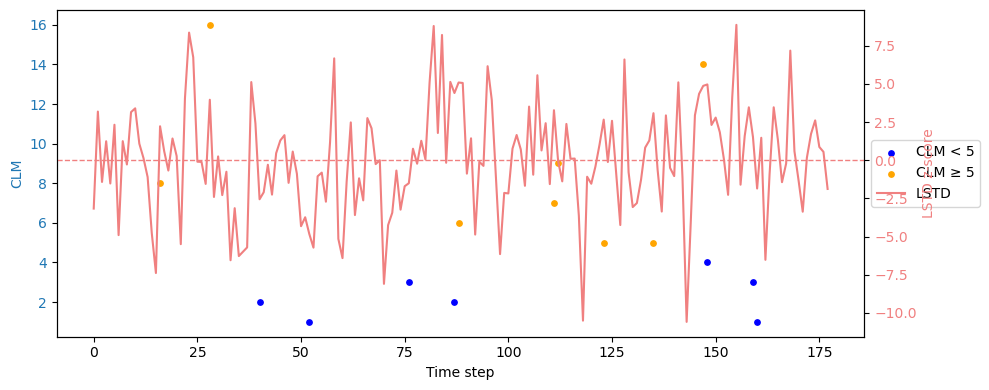

In [100]:
#x, y = (118, 61)
print('lat ', CLM5_GS_HSFndaysmonth['lat'][y].values, 'lon ',CLM5_GS_HSFndaysmonth['lon'][x].values)
clm = clmsample[y,x, :].values
lstd = anom_LSTD[:, y,x].values

t = np.arange(len(clm))

# Mask only the NaNs in CLM
mask = np.isfinite(clm)

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()


# Split CLM by threshold
below = mask & (clm < 5)
above = mask & (clm >= 5)

# CLM (left axis)
ax1.scatter(t[below], clm[below], s=15, color='blue', label='CLM < 5')
ax1.scatter(t[above], clm[above], s=15, color='orange', label='CLM ≥ 5')
ax1.set_ylabel("CLM", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# LSTD (right axis)
ax2.plot(t, lstd, color='lightcoral', lw=1.5, label='LSTD')
ax2.set_ylabel("LSTD z-score", color='lightcoral')
ax2.tick_params(axis='y', labelcolor='lightcoral')
ax2.axhline(0, color='lightcoral', linestyle='--', linewidth=1)
ax1.set_xlabel("Time step")

# Combined legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='center left',bbox_to_anchor=(1.0, 0.5))

plt.tight_layout()
plt.show()

### Trigger analysis maps

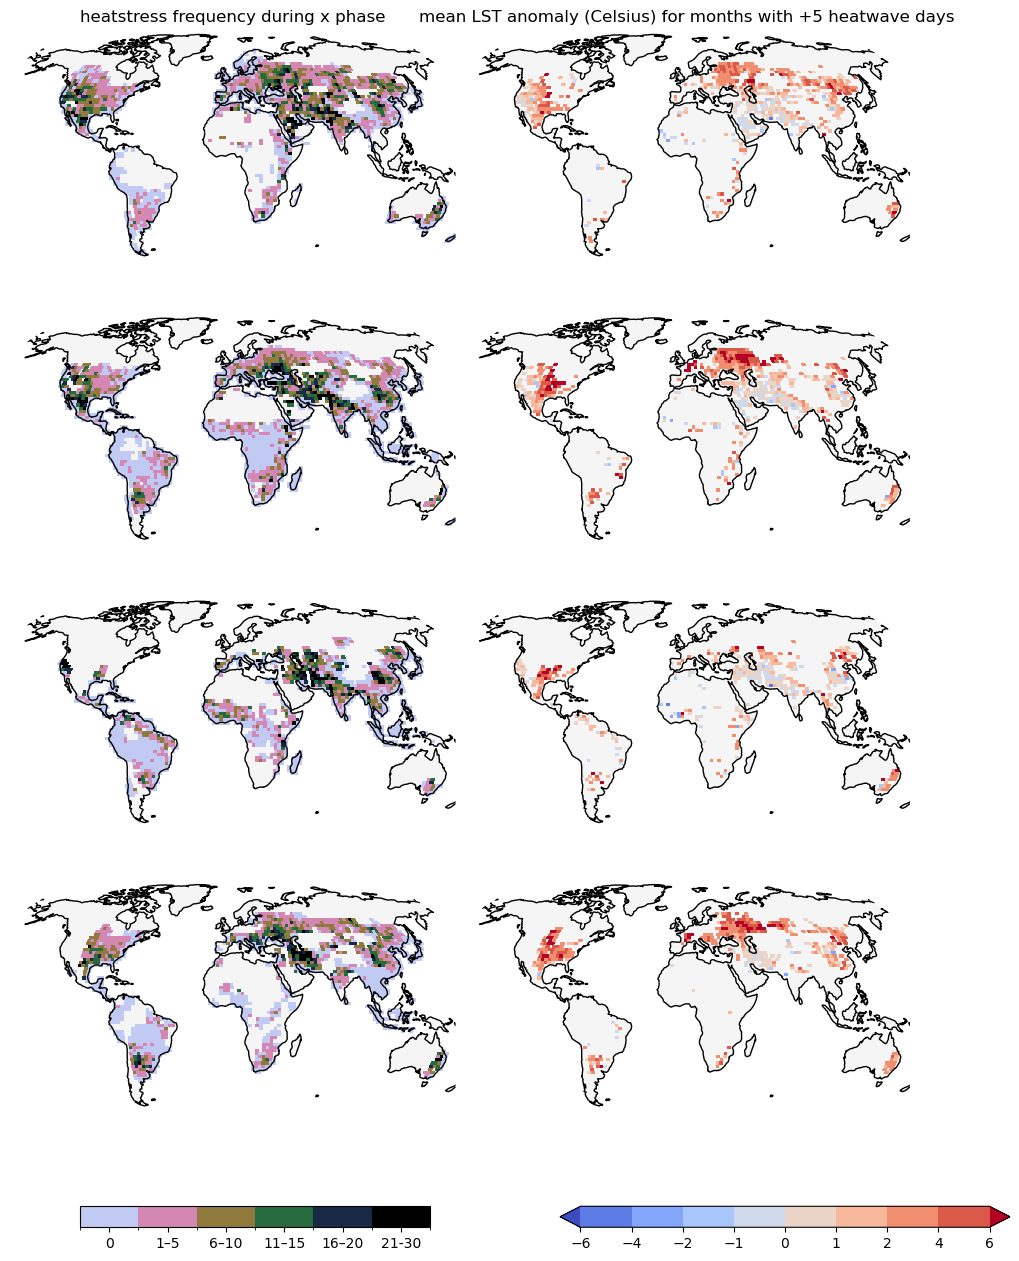

In [35]:
exps = {
    'GS': (CLM5_GS, CLM5_GS_HSFndaysmonth),
    'GF': (CLM5_GF, CLM5_GF_HSFndaysmonth),
    '30': (CLM5_30, CLM5_30_HSFndaysmonth)
}
expname = 'GS'
CLM5_HSF_crops, CLM_HS_month = exps[expname]

# ----- plot maps


#-- colormap for categorical plots
bounds = [0,1,6,11,16,20,31]
labels = ['0', '1–5', '6–10', '11–15', '16–20', '21-30']
base_cmap = plt.get_cmap("cubehelix_r")
colors = base_cmap(np.linspace(0.2, 1, len(bounds)-1))
cmap_occ = mcolors.ListedColormap(colors)
norm_occ = mcolors.BoundaryNorm(bounds, cmap_occ.N)

# colormap for second column
bounds2 = [-6,-4, -2, -1, 0, 1, 2, 4, 6]
base = plt.get_cmap("coolwarm", len(bounds2)+1)  # 10 colors
colors2 = base(np.arange(len(bounds2)+1))

cmap_occ2 = mcolors.ListedColormap(colors2)

norm_occ2 = mcolors.BoundaryNorm(
    bounds2,
    cmap_occ2.N,
    extend="both"
)

fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(10,14),
    subplot_kw={"projection": ccrs.Robinson()}
)

fig.subplots_adjust(
    top=0.92,    # space for figure title
    bottom=0.12, # space for horizontal colorbars
    left=0.05,   # optional left padding
    right=0.95,  # optional right padding
    hspace=0.05, # vertical spacing between rows
    wspace=0.02  # horizontal spacing between columns
)

for crop in range(4):

    # --- compute differences ---
    #HS trigger
    HSF_ndays     = CLM5_HSF_crops['HSF_ndays'][crop,:,:,:]
    #LST filter on anomalous heat days
    HS_month      = CLM_HS_month['HSF_ndays'][crop,:,:,:]

    # --- metric 1: occurrences years ---
    HS_threshold = HSF_ndays > 1
    HSF_freq = (HS_threshold).sum(dim='year')  #HSF_ndays.where(HSF_ndays > 0).count(dim='year')
    HSF_freq = HSF_freq.where(HSF_ndays.max(dim='year')>=0)


    # ---------- COLUMN 1 ----------
    ax = axes[crop,0]

    p1 = HSF_freq.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap_occ,
        norm=norm_occ,
        add_colorbar=False
    )
    
    ax.add_feature(cfeature.LAND, facecolor='whitesmoke', edgecolor='none')
    ax.add_feature(cfeature.OCEAN, facecolor='white', edgecolor='none')
    ax.coastlines()
    ax.set_extent([-125, 155, -50, 90])
    ax.spines['geo'].set_visible(False)
    if crop==0:
        ax.set_title("heatstress frequency during x phase")
    else: 
        ax.set_title("")

    # ---------- COLUMN 2 ----------
    ax = axes[crop,1]

    # align on time to get machting number of months:
    LSTD_zscore, HS_month = xr.align(
                            anom_LSTD ,
                            HS_month,
                            join="inner")

    # select LST months in which > 5 number of HS days are simulated in CLM experiment
    LST_stdanom = (
                    anom_LSTD
                    .where(HS_month > 5)
                    .groupby('time.year')
                    .mean('time')
                    .mean('year')
            )
    p2          = LST_stdanom.plot(
                    ax=ax,
                    transform=ccrs.PlateCarree(),
                    cmap=cmap_occ2,
                    norm=norm_occ2,
                    add_colorbar=False)
    
    ax.add_feature(cfeature.LAND, facecolor='whitesmoke', edgecolor='none')
    ax.add_feature(cfeature.OCEAN, facecolor='white', edgecolor='none')
    ax.coastlines()
    ax.set_extent([-125, 155, -50, 90])
    ax.spines['geo'].set_visible(False)
    if crop==0:    
        ax.set_title('mean LST anomaly (Celsius) for months with +5 heatwave days')
    else: 
        ax.set_title('')

# -------- COLORBARS --------
# Adjust spacing so there is room for colorbars
fig.subplots_adjust(bottom=0.12)

# colorbar positions (x, y, width, height)
cbar_ax1 = fig.add_axes([0.12, 0.05, 0.35, 0.015])
cbar_ax2 = fig.add_axes([0.60, 0.05, 0.45, 0.015])

cbar2 = fig.colorbar(p2, cax=cbar_ax2, orientation='horizontal',extend='both')


#put labels in cbar 1:
tick_locs = [
    (bounds[0] + bounds[1]) / 2,
    (bounds[1] + bounds[2]) / 2,
    (bounds[2] + bounds[3]) / 2,
    (bounds[3] + bounds[4]) / 2,
    (bounds[4] + bounds[5]) / 2,
    (bounds[5] + bounds[6]) / 2,
]

cbar1 = fig.colorbar(
    p1,
    cax=cbar_ax1,
    orientation='horizontal',
    ticks=tick_locs
)

cbar1.set_ticklabels(labels)
cbar2.set_ticks([-6, -4, -2, -1, 0, 1, 2, 4, 6])

plt.savefig(f'{root}/paper1/figs/HSF_freq_LSTCelsius_mean_{expname}_{YR1}_{YR2}.jpeg',dpi=400)

plt.show()

### Trigger analysis boxplots

#### HS length

In [41]:
# decide on max or median
stat = 'max'

def calc_HW_data(HSF_ndays, metric='median'):
    HS_threshold  = HSF_ndays >1
    HSF_frequency = (HS_threshold).sum(dim='year')
    if metric == 'median':
        HSF_stat      = HSF_ndays.where(HS_threshold).median(dim='year')
    elif metric == 'max':
        HSF_stat      = HSF_ndays.where(HS_threshold).max(dim='year')
    return HSF_frequency, HSF_stat

HSF_GS_freq, HSF_GS_stat = calc_HW_data(CLM5_GS['HSF_ndays'], stat)
HSF_GF_freq, HSF_GF_stat = calc_HW_data(CLM5_GF['HSF_ndays'], stat)
HSF_30_freq, HSF_30_stat = calc_HW_data(CLM5_30['HSF_ndays'], stat)

In [42]:
HSF_freq_groups = [1, 6, 11, 16, 21, 31]
labels          = ['1–5', '6–10', '11–15', '16–20', '21–30']

datasets = {
    'GS': (HSF_GS_freq, HSF_GS_stat),
    'GF': (HSF_GF_freq, HSF_GF_stat),
    '30': (HSF_30_freq, HSF_30_stat),
}
counts = {name: [] for name in datasets}

# Collect data for each frequency bin
box_data = {name: [] for name in datasets}
for name, (freq, mean) in datasets.items():
    freq_vals = freq.values.ravel()
    mean_vals = mean.values.ravel()

    # Remove NaNs
    mask = (
            np.isfinite(freq_vals)
            & np.isfinite(mean_vals)
            & (freq_vals > 0)
        )
    freq_vals = freq_vals[mask]
    mean_vals = mean_vals[mask]

    for lower, upper in zip(HSF_freq_groups[:-1], HSF_freq_groups[1:]):
        idx = (freq_vals >= lower) & (freq_vals < upper)
        box_data[name].append(mean_vals[idx])
        counts[name].append(np.sum(idx))

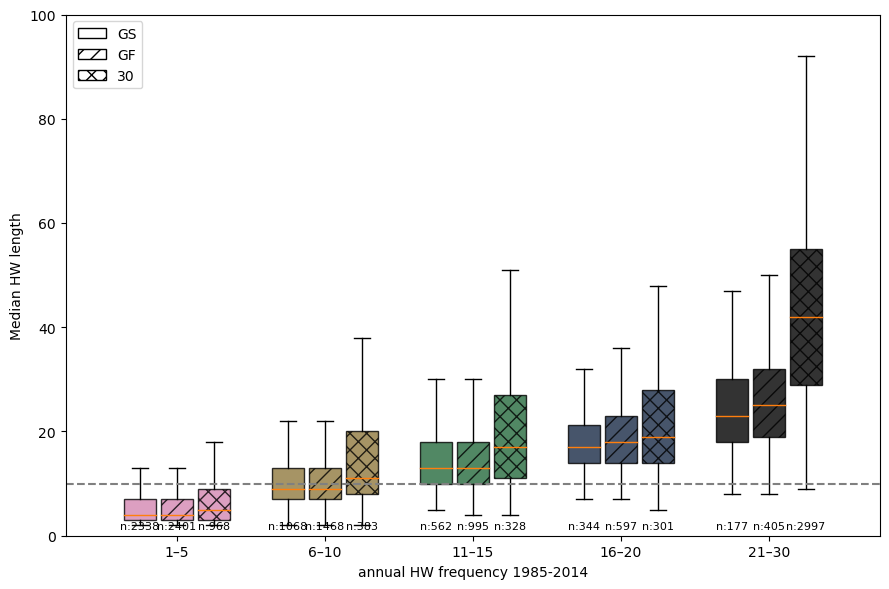

In [43]:
base_cmap = plt.get_cmap("cubehelix_r")

#Original color scheme
bounds_original = [0, 1, 5, 10, 15, 20,31]

colors_original = base_cmap(
    np.linspace(0.2, 1, len(bounds_original)-1)
)

# Remove 0-1 color
colors_new = colors_original[1:]

# Add 20-30 using the same color as 15-20
#colors_new = np.vstack([colors_new, colors_new[-1]])


fig, ax = plt.subplots(figsize=(9, 6))

width = 0.25
n_groups = len(labels)
group_centers = np.arange(n_groups)

bp_gs = ax.boxplot(
    box_data['GS'],
    positions=group_centers - width,
    widths=0.22,
    patch_artist=True,
    showfliers=False
)

bp_gf = ax.boxplot(
    box_data['GF'],
    positions=group_centers,
    widths=0.22,
    patch_artist=True,
    showfliers=False
)

bp_30 = ax.boxplot(
    box_data['30'],
    positions=group_centers + width,
    widths=0.22,
    patch_artist=True,
    showfliers=False
)

hatches = ['', '//', 'xx']
boxsets = [bp_gs, bp_gf, bp_30]
edgecolors  = ['white', 'grey', 'black']
# Color all three boxes in each frequency group identically
for ds_idx, bp in enumerate(boxsets):
    for i in range(n_groups):

        # frequency coloring (RESTORE THIS)
        bp['boxes'][i].set_facecolor(colors_new[i])
        bp['boxes'][i].set_edgecolor('black')

        # dataset encoding (GS/GF/30)
        bp['boxes'][i].set_hatch(hatches[ds_idx])
        bp['boxes'][i].set_alpha(0.8)



ax.set_xticks(group_centers)
ax.set_ylim(0, 100)
ax.set_xticklabels(labels)
ax.set_xlabel("annual HW frequency 1985-2014")
ax.set_ylabel("Median HW length")


# Create legend for GS/GF/30

legend_elements = [
    Patch(facecolor='white', edgecolor='black', hatch=hatches[0], label='GS'),
    Patch(facecolor='white', edgecolor='black', hatch=hatches[1], label='GF'),
    Patch(facecolor='white', edgecolor='black', hatch=hatches[2], label='30'),
]

ax.legend(handles=legend_elements)
ax.axhline(10, color='grey', linestyle='--')

ymin, ymax = ax.get_ylim()
y_text = ymin + 0.01 * (ymax - ymin)
datasets_names = ['GS', 'GF', '30']
offsets = [-width, 0, width]

for j, name in enumerate(datasets_names):
    for i in range(n_groups):

        ax.text(
            group_centers[i] + offsets[j],
            y_text,
            f"n:{counts[name][i]}",
            ha='center',
            va='bottom',
            fontsize=8,
            rotation=0   # horizontal
        )

plt.tight_layout()
plt.savefig(f'{root}/paper1/figs/HW_{stat}_boxplots.jpeg',dpi=400)
plt.show()

#### irrigated vs rainfed

In [19]:
datasets = {
    "GS": HSF_GS_freq,
    "GF": HSF_GF_freq,
    "30": HSF_30_freq
}

base_crops = ['spring_wheat', 'corn', 'rice', 'soybean']
irr_crops  = ['irrigated_spring_wheat', 'irrigated_corn',
              'irrigated_rice', 'irrigated_soybean']

all_records = []

for name, ds in datasets.items():
    for b, i in zip(base_crops, irr_crops):
        ds_rf =  ds.sel(crop=b)
        ds_ir = ds.sel(crop=i)
        diff = ds_rf.where(ds_rf>0) - ds_ir.where(ds_ir>0)

        # flatten spatial dims
        diff_flat = diff.values.ravel()

        df = pd.DataFrame({
            "diff": diff_flat,
            "crop": b,
            "dataset": name
        })

        all_records.append(df)

df_all = pd.concat(all_records, ignore_index=True)

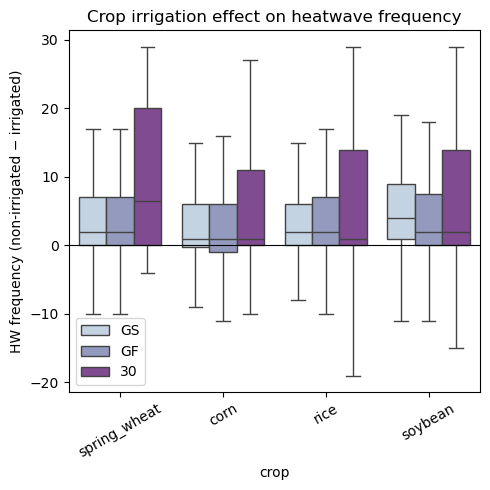

In [20]:
plt.figure(figsize=(5,5))

custom_palette = sns.color_palette("BuPu", n_colors=3)

sns.boxplot(
    data=df_all,
    x="crop",
    y="diff",
    hue="dataset",
    showfliers=False,
   palette=custom_palette,
    ) 

plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("HW frequency (non-irrigated − irrigated)")
plt.title("Crop irrigation effect on heatwave frequency")
plt.legend(title=None)
plt.xticks(rotation=30)
plt.tight_layout()
#plt.savefig(f'/dodrio/scratch/users/vsc10951/sderoos/paper1/figs/HWfreq_rf_irr.jpeg',dpi=400)
plt.show()